In [740]:
!python -m pip install --upgrade pip
!python -m pip install dtaidistance
!python -m pip install pandas
!python -m pip install numpy
!python -m pip install matplotlib
!python -m pip install whisper-timestamped
!python -m pip install flask
!python -m pip install audio-similarity


In [741]:
!python -m pip install flask_cors
!python -m pip install flask_restful
!python -m pip install pydub

In [742]:
!python -m pip install librosa
!python -m pip install resampy
!python -m pip install pytube

In [743]:

!python -m pip install praat-parselmouth
!python -m pip install scipy
!python -m pip install python_speech_features

In [744]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import whisper_timestamped as whisper
from flask import Flask, send_from_directory, url_for, request
from werkzeug.utils import secure_filename
from flask_cors import CORS #comment this on deployment
from flask_restful import reqparse
from flask import jsonify
import pandas as pd
import io
from ast import literal_eval
import numpy as np
import heapq
import json
import math
import ssl
#from ibm_cloud_sdk_core.authenticators import IAMAuthenticator
#from ibm_watson import SpeechToTextV1

from pydub import AudioSegment
import librosa
from scipy.io import wavfile
import resampy
from scipy import interpolate
#import pysptk
from pytube import YouTube
import os
import whisper_timestamped as whisper
from audio_similarity import AudioSimilarity
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
from dtaidistance import dtw_ndim

import parselmouth


In [745]:
SONNET1="Sonnet66Segment1.wav" #Same audio, same phrase, section 1
SONNET2="Sonnet66Segment2.wav" #Same audio, same phrase, section 2
OZYMANDIAS1_1= "ozymandias_1_1.wav"#Sample 1, phrase 1
OZYMANDIAS1_2= "ozymandias_1_2.wav"#Sample 1, phrase 2
OZYMANDIAS1_3= "ozymandias_1_3.wav"#Sample 1, phrase 3
OZYMANDIAS2_1= "ozymandias_2_1.wav"#Sample 2, phrase 1
OZYMANDIAS2_2= "ozymandias_2_2.wav"#Sample 2, phrase 2
OZYMANDIAS2_3= "ozymandias_2_3.wav"#Sample 2, phrase 3
RHYME1="Rhyme1.wav" #Similar phrase, diff speaker
RHYME2="Rhyme2.wav" #Similar phrase, diff speaker

In [746]:
import numpy as np
model = whisper.load_model("base") #Try gpu

In [747]:
def pre_emphasis(signal, pre_emphasis_coefficient=0.97):
    return np.append(signal[0], signal[1:] - pre_emphasis_coefficient * signal[:-1])

In [748]:
def framing(signal, frame_size, frame_stride, sample_rate):
    frame_length, frame_step = frame_size * sample_rate, frame_stride * sample_rate
    signal_length = len(signal)
    frame_length = int(round(frame_length))
    frame_step = int(round(frame_step))
    num_frames = int(np.ceil(float(np.abs(signal_length - frame_length)) / frame_step))

    pad_signal_length = num_frames * frame_step + frame_length
    z = np.zeros((pad_signal_length - signal_length))
    pad_signal = np.append(signal, z)
    
    indices = np.tile(np.arange(0, frame_length), (num_frames, 1)) + np.tile(np.arange(0, num_frames * frame_step, frame_step), (frame_length, 1)).T
    frames = pad_signal[indices.astype(np.int32, copy=False)]
    return frames

In [749]:
def windowing(frames):
    return frames * np.hamming(frames.shape[1])

In [750]:
def power_spectrum(frames, NFFT):
    mag_frames = np.absolute(np.fft.rfft(frames, NFFT))  # Magnitude of the FFT
    pow_frames = ((1.0 / NFFT) * (mag_frames ** 2))  # Power Spectrum
    return pow_frames

In [751]:
def mel_filter_bank(pow_frames, nfilt, NFFT, sample_rate):
    low_freq_mel = 0
    high_freq_mel = (2595 * np.log10(1 + (sample_rate / 2) / 700))  # Convert Hz to Mel
    mel_points = np.linspace(low_freq_mel, high_freq_mel, nfilt + 2)  # Equally spaced in Mel scale
    hz_points = (700 * (10**(mel_points / 2595) - 1))  # Convert Mel to Hz
    bin = np.floor((NFFT + 1) * hz_points / sample_rate)

    fbank = np.zeros((nfilt, int(np.floor(NFFT / 2 + 1))))
    for m in range(1, nfilt + 1):
        f_m_minus = int(bin[m - 1])   # left
        f_m = int(bin[m])             # center
        f_m_plus = int(bin[m + 1])    # right

        for k in range(f_m_minus, f_m):
            fbank[m - 1, k] = (k - bin[m - 1]) / (bin[m] - bin[m - 1])
        for k in range(f_m, f_m_plus):
            fbank[m - 1, k] = (bin[m + 1] - k) / (bin[m + 1] - bin[m])

    filter_banks = np.dot(pow_frames, fbank.T)
    filter_banks = np.where(filter_banks == 0, np.finfo(float).eps, filter_banks)  # Numerical Stability
    filter_banks = 20 * np.log10(filter_banks)  # dB
    return filter_banks

In [752]:
from scipy.fftpack import dct
def compute_mfcc(filter_banks, num_ceps):
    mfcc = dct(filter_banks, type=2, axis=1, norm='ortho')[:, 1 : (num_ceps + 1)]
    return mfcc

In [753]:
def amplitude_envelope(signal, frame_size, hop_length):
    """Calculate the amplitude envelope of a signal with a given frame size nad hop length."""
    amplitude_envelope = []

    # calculate amplitude envelope for each frame
    for i in range(0, len(signal), hop_length):
        amplitude_envelope_current_frame = max(signal[i:i+frame_size])
        amplitude_envelope.append(amplitude_envelope_current_frame)


    return np.array(amplitude_envelope)

In [754]:
def get_derivative_of_list(list, time_step):    
    der_list=[]
    if(len(list)==0): 
        return der_list
    elif len(list)==1:
        der_list.append(0)
        return der_list
    der_list.append((list[1]-list[0])/time_step)
    for i in range(1,len(list)-1):
        der_list.append((list[i+1]-list[i-1])/(time_step*2)) #Takes the slope of secant line of adjacent two points
    der_list.append(list[len(list)-1]-list[2]/(time_step))
    return der_list

In [1320]:
def fast_fourier_transform_denoise(lst,len,time_step):
    #print("LIST: ",lst)
    h = np.fft.fft(lst)
    PSD = h * np.conj(h) / len
    freq = (1 / (time_step * len)) * np.arange(len)

    # Normalize frequency (0 to 1 scale) and PSD
    freq_norm = freq / freq[-1]
    PSD_norm = PSD / np.max(PSD)
    # Adaptive thresholding (e.g., using 95th percentile)
    threshold = np.percentile(PSD_norm.real, 95)
    PSD_filtered = np.where(PSD_norm.real < threshold, 0, PSD)

    # Apply the filter to the FFT components
    h_filtered = np.where(PSD_norm.real < threshold, 0, h)

    # Inverse FFT to time domain
    H_clean = np.fft.ifft(h_filtered).real
    return H_clean


In [1321]:
def process_audio_data(filename):
    MIN_SENTENCE_CONFIDENCE_THRESHOLD=0.4 #For sentence confidence. If model confidence is below the value, sentence is ignored.
    MIN_WORD_CONFIDENCE_THRESHOLD=0.3 #For word confidence. If model confidence is below the value, individual word is ignored.
    

    #TRANSCRIPTION PROCESS
    audio=whisper.load_audio(filename)
    results=whisper.transcribe(model, audio, language="en")

    #AMPLITUDE CALCULATION
    """audio,sr = librosa.load(filename)"""
    FRAME_SIZE = 128
    HOP_LENGTH=128
    SAMPLE_RATE=16000.0   

    snd = parselmouth.Sound(filename)
    amplitude_values = amplitude_envelope(audio, FRAME_SIZE, HOP_LENGTH)
    #Figure out units TODO
    frames = range(len(amplitude_values))
    t = librosa.frames_to_time(frames,sr=SAMPLE_RATE, hop_length=HOP_LENGTH)
    amplitude_values=fast_fourier_transform_denoise(amplitude_values,len(amplitude_values),HOP_LENGTH/SAMPLE_RATE)

    #tck = interpolate.splrep(t, amplitude_values, s=0)
    #xnew = np.linspace(0, t[-1], num=len(amplitude_values))
    #amplitude_values = interpolate.splev(xnew, tck, der=0)


    pitch = snd.to_pitch(time_step=(HOP_LENGTH/SAMPLE_RATE), pitch_floor=50, pitch_ceiling=350)
    pitch_values = pitch.selected_array['frequency']

    tckp = interpolate.splrep(pitch.xs(), pitch_values, s=0)
    xnewp = np.linspace(0, t[-1], num=len(pitch_values))
    pitch_values = interpolate.splev(xnewp, tckp, der=0)


    #Interpolate pitch
    if(len(pitch_values)>len(amplitude_values)):
        pitch_values=pitch_values[0:len(amplitude_values)]
        t=t[0:len(amplitude_values)]
        
    if(len(pitch_values)<len(amplitude_values)):
        amplitude_values=amplitude_values[0:len(pitch_values)]
        t=t[0:len(pitch_values)]
    print("Len1: "+str(len(amplitude_values))+" Len2: "+str(len(pitch_values)))
    
    avg_amp=np.nanmean(amplitude_values)
    avg_pitch=np.nanmean([p if (p>=0) else np.nan for p in pitch_values]) #Removes 0s

    amplitude_values=amplitude_values/avg_amp
    pitch_values=pitch_values/avg_pitch
    for i in range(len(pitch_values)):
        if pitch_values[i]<0:
            pitch_values[i]=0


    #Transcription Values Calculation
    

    lst = []

    for i in range(len(results["segments"])):
        if results["segments"][i]["confidence"]<MIN_SENTENCE_CONFIDENCE_THRESHOLD:
            print("Skipping Sentence "+str(i))
            continue #Skips sentence fully
        for j in range(len(results["segments"][i]["words"])):
            if results["segments"][i]["words"][j]["confidence"]<MIN_WORD_CONFIDENCE_THRESHOLD:
                print("Skipping Word "+str(i)+ ", "+str(j))
                continue #Skips word 
            lst.append([results["segments"][i]["words"][j]["text"],results["segments"][i]["words"][j]["start"],results["segments"][i]["words"][j]["end"],0,0,0,0,0,0,0]) #zero as placeholder for other values
            
    df_word = pd.DataFrame(lst, columns=['Word', 'Start', 'End','length','time_spent','std_time_spent','speed','post_space','amplitude','pitch'])
    


    df_word["length"] = df_word["Word"].apply(len)
    df_word['time_spent'] = df_word['End'] - df_word['Start']
    df_word['std_time_spent'] = df_word['time_spent']/df_word['length']
    df_word["speed"] = df_word["length"]/df_word["time_spent"]
    

    post =  df_word['Start'][1:].values - df_word['End'][:-1].values
    df_word["time"] = df_word["Start"] + (df_word["End"] - df_word["Start"])/2

    df_word['post_space'] = np.append(post,[0])
    
    inte = []
    pit = []

    for i in range(len(df_word)):
            t1 = df_word['Start'][i]
            t2 = df_word['End'][i]
            idx_amp = (t>t1) & (t<t2)

            #all_nan = np.all(np.isnan(amplitude_values[idx_amp]))
            #int_avg=0
            #if(not all_nan):
            int_avg = np.nanmean(amplitude_values[idx_amp])
            print(int_avg)

            norm_int_avg=int_avg/(avg_amp)
            inte.append(norm_int_avg)
            

            idx_p = (t>t1) & (t<t2)
            #pit_avg=0
            #all_nan2 = np.all(np.isnan(pitch_values[idx_p]))
            #if(not all_nan2):
            pit_avg = np.nanmean(pitch_values[idx_p])
            norm_pit_avg=(pit_avg/(avg_pitch))
            pit.append(norm_pit_avg)


    df_word['amplitude'] = inte
    df_word['pitch'] = pit
        
        
    return df_word, avg_amp, avg_pitch, t, amplitude_values,pitch_values

In [1322]:
# columns=['Word', 'Start', 'End','length','time_spent','std_time_spent','speed','post_space','amplitude','pitch']

METRICS=['amplitude']

In [1359]:
audioSample1=OZYMANDIAS1_3
audioSample2=OZYMANDIAS2_3

Loading comparison files:: 100%|██████████| 1/1 [00:00<00:00, 1002.94it/s]
Calculating zero crossing rate similarity...
Calculating rhythm similarity...
Calculating chroma similarity similarity...
Calculating energy envelope similarity...
Calculating spectral contrast similarity...
Calculating perceptual similarity...


Stent Weighted Audio Similarity: {'zcr_similarity': 0.9481141274513791, 'rhythm_similarity': 0.6450693890813196, 'chroma_similarity': 0.7032181620597839, 'energy_envelope_similarity': 0.4629233432403197, 'spectral_contrast_similarity': 0.8457420769296373, 'perceptual_similarity': 0.49205396486044095, 'swass': 0.6885576707075806}


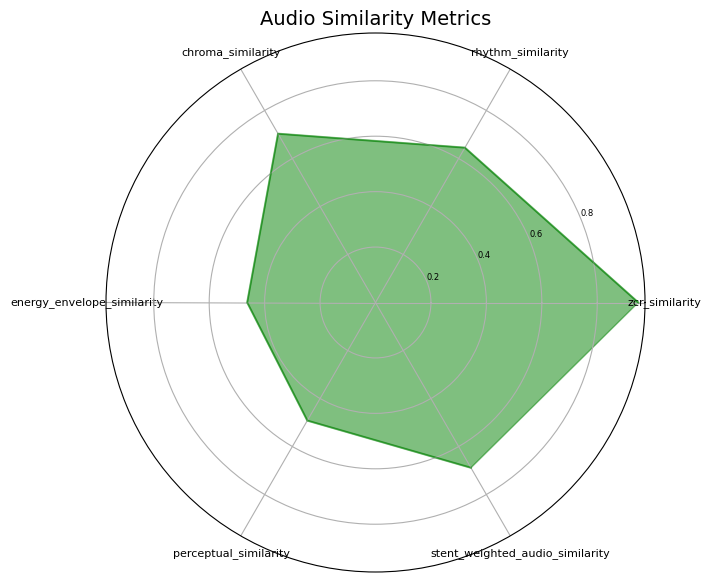

In [1360]:
from audio_similarity import AudioSimilarity

# Paths to the original and compariosn audio files/folders

original_path = audioSample1
compare_path = audioSample2

# Set the sample rate and weights for the metrics

sample_rate = 16000
weights = {
    'zcr_similarity': 0.2,
    'rhythm_similarity': 0.2,
    'chroma_similarity': 0.2,
    'energy_envelope_similarity': 0.1,
    'spectral_contrast_similarity': 0.1,
    'perceptual_similarity': 0.2
}

verbose = True # Show logs

# Create an instance of the AudioSimilarity class

audio_similarity = AudioSimilarity(original_path, compare_path, sample_rate, weights, verbose=verbose)

# Calculate a single metric

zcr_similarity = audio_similarity.zcr_similarity()

# Calculate the Stent Weighted Audio Similarity
#metrics='all'
similarity_score = audio_similarity.stent_weighted_audio_similarity(metrics='all') # You can select all metrics or just the 'swass' metric

print(f"Stent Weighted Audio Similarity: {similarity_score}")

audio_similarity.plot(metrics=None,
                      option='radar',
                      figsize=(10, 7),
                      color1='red',
                      color2='green',
                      dpi=100,
                      savefig=False,
                      fontsize=6,
                      label_fontsize=8,
                      title_fontsize=14, 
                      alpha=0.5, 
                      title='Audio Similarity Metrics')

In [1361]:
import numpy as np
import scipy.io.wavfile as wav
from scipy.fftpack import dct
#from python_speech_features import mfcc

# Load the audio file
sample_rate, signal = wav.read(audioSample1)
signal = signal[0:int(3.5 * sample_rate)]  # Keep the first 3.5 seconds

# Pre-emphasis
emphasized_signal = pre_emphasis(signal)

# Framing
frame_size = 0.025
frame_stride = 0.01
frames = framing(emphasized_signal, frame_size, frame_stride, sample_rate)

# Windowing
frames = windowing(frames)

# Fourier Transform and Power Spectrum
NFFT = 512
pow_frames = power_spectrum(frames, NFFT)

# Mel Filter Bank
nfilt = 40
filter_banks = mel_filter_bank(pow_frames, nfilt, NFFT, sample_rate)

# MFCCs
num_ceps = 12
mfcc1 = compute_mfcc(filter_banks, num_ceps)

In [1362]:
import numpy as np
import scipy.io.wavfile as wav
from scipy.fftpack import dct

# Load the audio file
sample_rate, signal = wav.read(audioSample2)
signal = signal[0:int(3.5 * sample_rate)]  # Keep the first 3.5 seconds

# Pre-emphasis
emphasized_signal = pre_emphasis(signal)

# Framing
frame_size = 0.025
frame_stride = 0.01
frames = framing(emphasized_signal, frame_size, frame_stride, sample_rate)

# Windowing
frames = windowing(frames)

# Fourier Transform and Power Spectrum
NFFT = 512
pow_frames = power_spectrum(frames, NFFT)

# Mel Filter Bank
nfilt = 40
filter_banks = mel_filter_bank(pow_frames, nfilt, NFFT, sample_rate)

# MFCCs
num_ceps = 12
mfcc2 = compute_mfcc(filter_banks, num_ceps)

In [1363]:
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
from dtaidistance import dtw_ndim
distance=dtw_ndim.distance_fast(mfcc1,mfcc2)
print(distance)

4158.368437287728


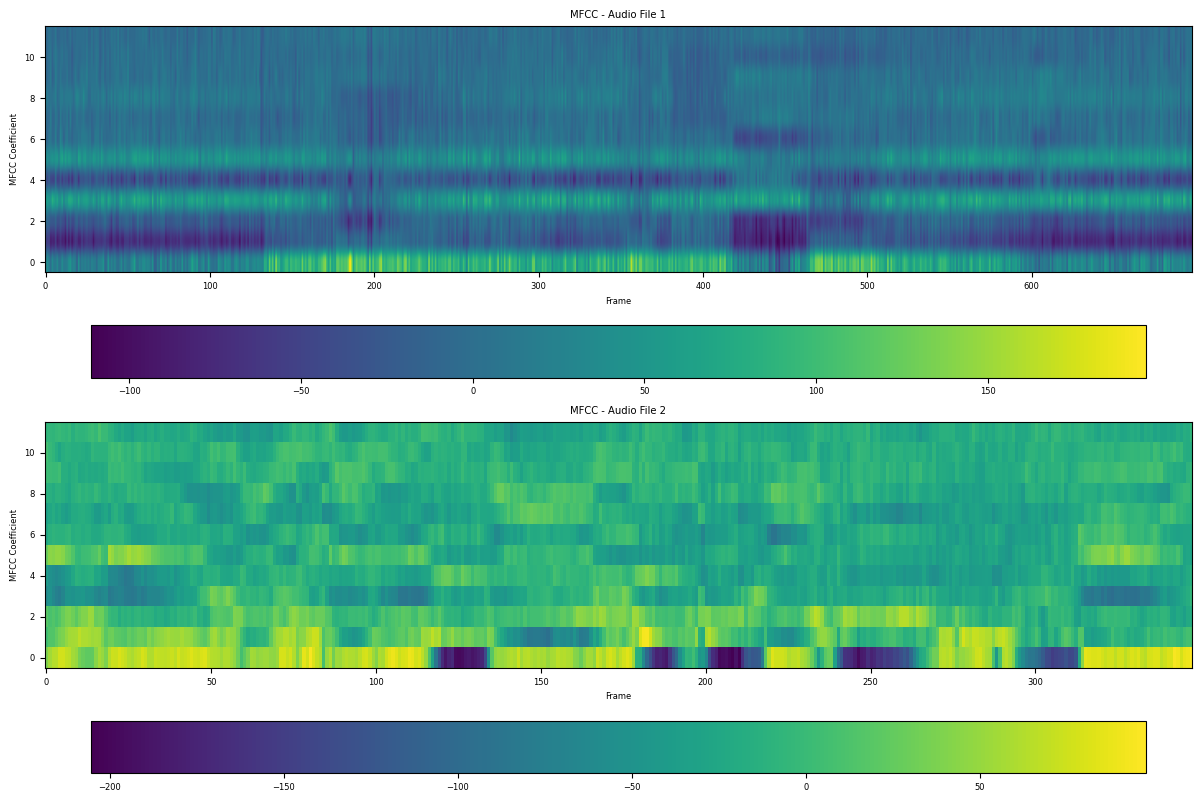

In [1364]:
import numpy as np
import scipy.io.wavfile as wav
import matplotlib.pyplot as plt
#from python_speech_features import mfcc
# Plot heatmaps
# Plot MFCC for audio file 1
fig, axs = plt.subplots(2, 1, figsize=(12, 8))

# Plot MFCC for audio file 1
im1 = axs[0].imshow(mfcc1.T, aspect='auto', origin='lower', cmap='viridis')
axs[0].set_title('MFCC - Audio File 1')
axs[0].set_xlabel('Frame')
axs[0].set_ylabel('MFCC Coefficient')
plt.colorbar(im1, ax=axs[0], orientation='horizontal')

# Plot MFCC for audio file 2
im2 = axs[1].imshow(mfcc2.T, aspect='auto', origin='lower', cmap='viridis')
axs[1].set_title('MFCC - Audio File 2')
axs[1].set_xlabel('Frame')
axs[1].set_ylabel('MFCC Coefficient')
plt.colorbar(im2, ax=axs[1], orientation='horizontal')

plt.tight_layout()
plt.show()

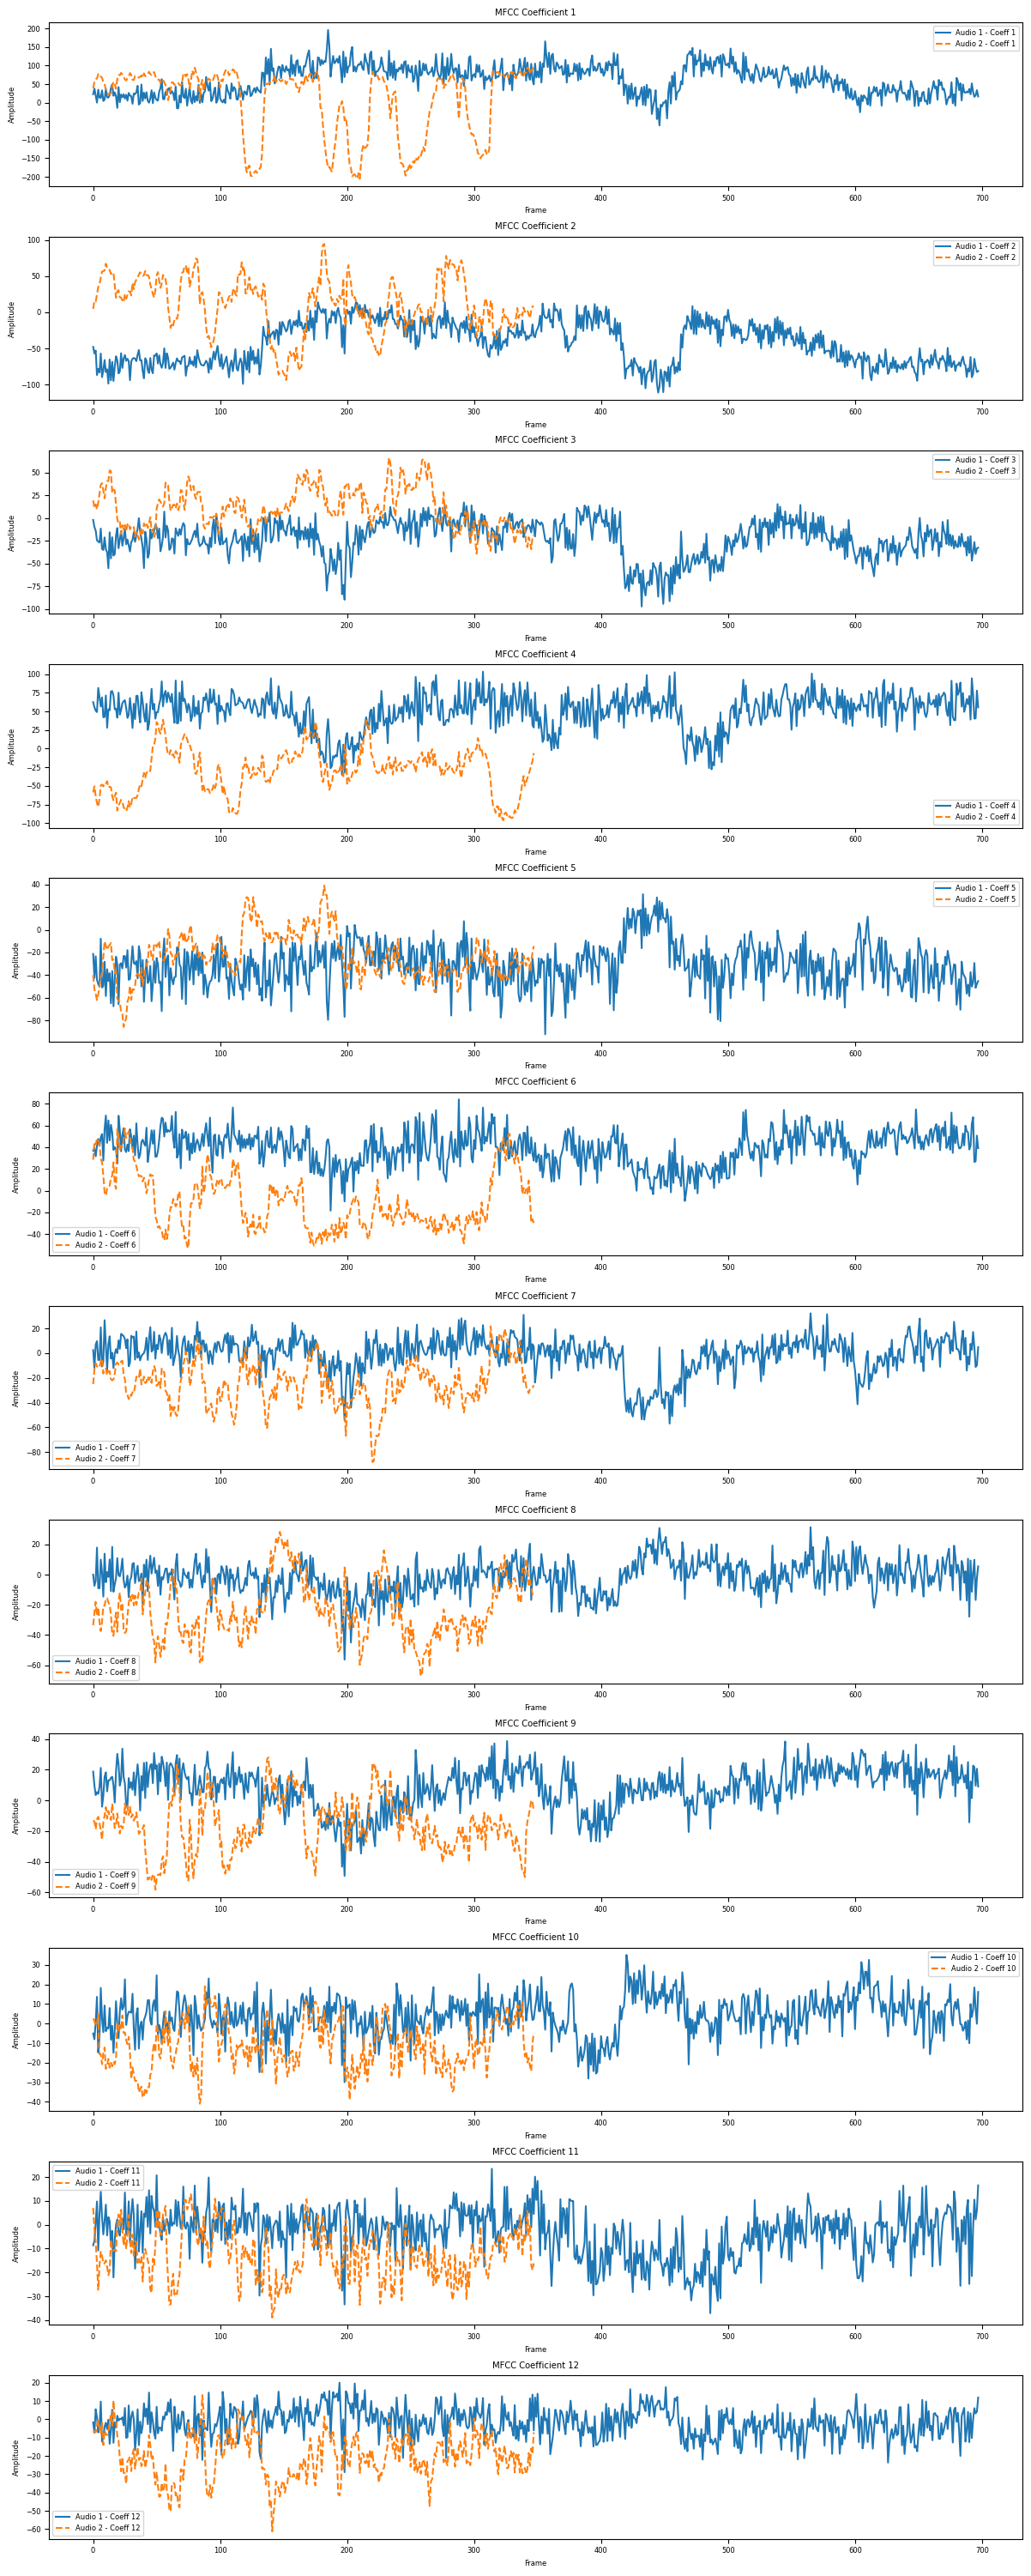

In [1365]:
num_coeffs_to_plot = 12

# Plot overlapping MFCC coefficients
plt.figure(figsize=(12, 30))
for i in range(num_coeffs_to_plot):
    plt.subplot(num_coeffs_to_plot, 1, i + 1)
    plt.plot(mfcc1[:, i], label=f'Audio 1 - Coeff {i+1}')
    plt.plot(mfcc2[:, i], label=f'Audio 2 - Coeff {i+1}', linestyle='--')
    plt.title(f'MFCC Coefficient {i+1}')
    plt.xlabel('Frame')
    plt.ylabel('Amplitude')
    plt.legend()
plt.tight_layout()
plt.show()

In [1366]:
"""from scipy.spatial.distance import euclidean
distances = np.array([[euclidean(mfcc1[i], mfcc2[j]) for j in range(mfcc2.shape[0])] for i in range(mfcc1.shape[0])])

# Plot distance heatmap
plt.figure(figsize=(12, 8))
plt.imshow(distances, aspect='auto', origin='lower', cmap='hot')
plt.title('MFCC Frame-to-Frame Distance')
plt.xlabel('Frame (Audio 2)')
plt.ylabel('Frame (Audio 1)')
plt.colorbar(label='Euclidean Distance')
plt.show()"""

"from scipy.spatial.distance import euclidean\ndistances = np.array([[euclidean(mfcc1[i], mfcc2[j]) for j in range(mfcc2.shape[0])] for i in range(mfcc1.shape[0])])\n\n# Plot distance heatmap\nplt.figure(figsize=(12, 8))\nplt.imshow(distances, aspect='auto', origin='lower', cmap='hot')\nplt.title('MFCC Frame-to-Frame Distance')\nplt.xlabel('Frame (Audio 2)')\nplt.ylabel('Frame (Audio 1)')\nplt.colorbar(label='Euclidean Distance')\nplt.show()"

In [1367]:
#CASE 1 Same audio, same phrase.
#Target Result: 0
from dtaidistance import dtw
from dtaidistance import dtw_visualisation as dtwvis
from dtaidistance import dtw_ndim

df_word1, _ , _, time1,amplitude1, pitch1=process_audio_data(audioSample1)
df_word2, _ , _, time2,amplitude2,pitch2 =process_audio_data(audioSample2) 

dAmplitude1=get_derivative_of_list(amplitude1,time1[1]-time1[0])
dPitch1=get_derivative_of_list(pitch1,time1[1]-time1[0])


dAmplitude2=get_derivative_of_list(amplitude2,time2[1]-time2[0])
dPitch2=get_derivative_of_list(pitch2,time2[1]-time2[0])

lst1=[amplitude1.astype(np.double)]#,np.array(dPitch1,dtype=np.double)]
lst2=[amplitude2.astype(np.double)]#,np.array(dPitch2,dtype=np.double)]
#lst1.append()
#lst2.append()
lst1=np.array(lst1,dtype=np.double).T
lst2=np.array(lst2,dtype=np.double).T

#lst1,lst2= interpolate_and_match_length(lst1,lst2)

print(f"Size of lst1: {lst1.shape}")
print(f"Size of lst2: {lst2.shape}")
#print(str(type()))#+str(amplitude2))
d = dtw_ndim.distance_fast(
  lst1,lst2
  #df_word1[METRICS].to_numpy(dtype=np.double),
  #df_word2[METRICS].to_numpy(dtype=np.double)
  )
print("Distance:" +str(d))

100%|██████████| 700/700 [00:01<00:00, 559.73frames/s]


Len1: 868 Len2: 868
Skipping Word 0, 5
2.411184487499928
1.8315260456045965
1.3600583593314044
1.7169478534695974
0.5323474962495226
2.225929606558908


100%|██████████| 500/500 [00:01<00:00, 384.92frames/s]

Len1: 618 Len2: 618
1.4999178995852853
1.9773255937119512
1.256562042942455
1.3211886402361488
1.0279647027070997
0.7081450545567596
0.8574166413060663
0.7827067976975383
Size of lst1: (868, 1)
Size of lst2: (618, 1)
Distance:16.295778091907763


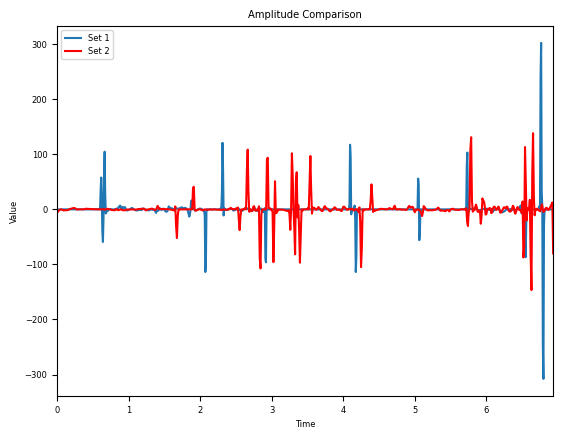

In [1368]:
plt.figure()  # Create a new figure for each combination of segments
plottedIndex=1

max_x_range=time1[-1]
dat = dPitch1#lst1[:,plottedIndex]

time_sequence = np.linspace(0, max_x_range, num=len(dat))

plt.plot(time_sequence, dat, label=f'Set 1')  # Adjust label as necessary

dat2 = dPitch2#lst2[:,plottedIndex]
time_sequence2 = np.linspace(0, max_x_range, num=len(dat2))

plt.plot(time_sequence2, dat2, c='red', label=f'Set 2')  # Adjust label as necessary
plt.xlim(0, max_x_range)  # Set the x-axis limits to the maximum found

plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'Amplitude Comparison')
plt.show()

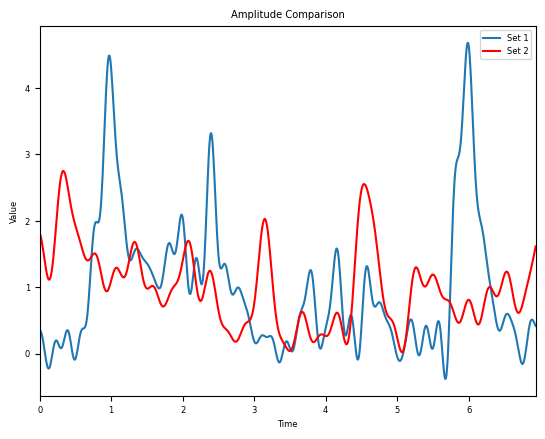

In [1369]:
plt.figure()  # Create a new figure for each combination of segments
plottedIndex=0

max_x_range=time1[-1]
dat = lst1[:,plottedIndex]

time_sequence = np.linspace(0, max_x_range, num=len(dat))

plt.plot(time_sequence, dat, label=f'Set 1')  # Adjust label as necessary

dat2 = lst2[:,plottedIndex]
time_sequence2 = np.linspace(0, max_x_range, num=len(dat2))
    
plt.plot(time_sequence2, dat2, c='red', label=f'Set 2')  # Adjust label as necessary
plt.xlim(0, max_x_range)  # Set the x-axis limits to the maximum found

plt.legend()
plt.xlabel('Time')
plt.ylabel('Value')
plt.title(f'Amplitude Comparison')
plt.show()

(<Figure size 1000x1000 with 4 Axes>, [<Axes: >, <Axes: >, <Axes: >, <Axes: >])

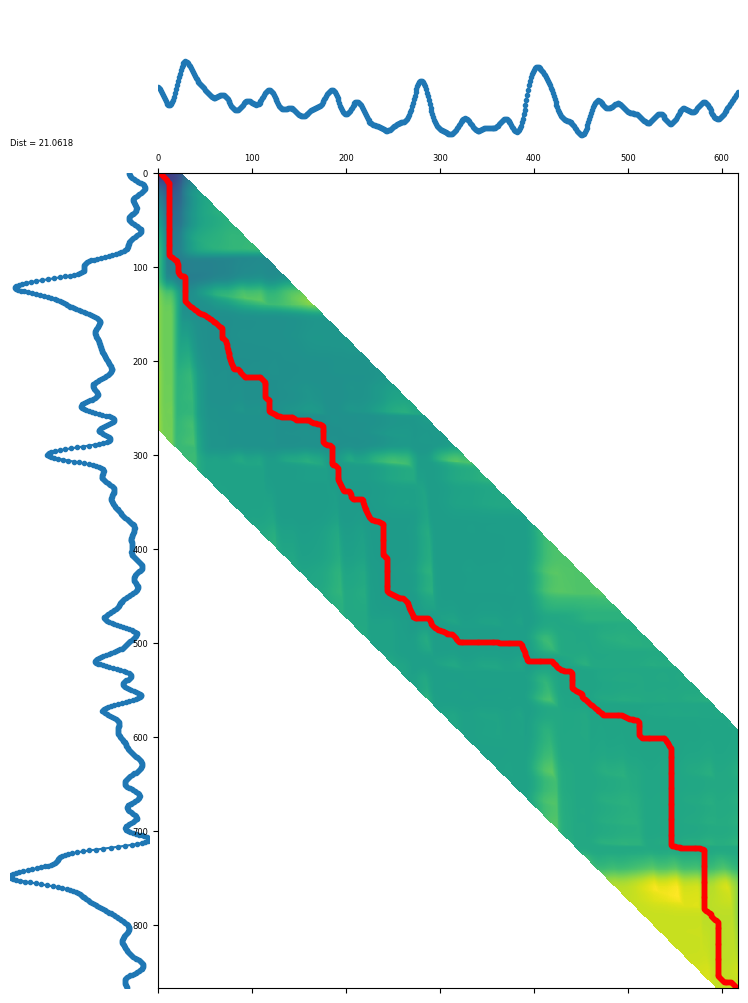

In [1370]:
d, paths = dtw.warping_paths(lst1, lst2, window=25, psi=2)
best_path = dtw.best_path(paths)
dtwvis.plot_warpingpaths(lst1, lst2, paths, best_path)